**Black Friday EDA & Feature Engineering**

Cleaning and preparing the data for model training

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

**Problem Statement** : A retail company "ABC Private Limited" wants to understand the customer purchase behaviour (specially, purchase amount) against various product of different categories. They have shared purchare summary of various customers for selected high volume products from last month. The data set also contains customer demographics (age, gender, marital status, city_type, stay_in_current_city), product details (product_id and product category) and Total purchase_amount from last month.

Now, they want to build a model to predict the purchase amount of customers against the products which help them to create personalized offer for customers againt different products.

In [3]:
#importing the dataset 
df_train=pd.read_csv('Downloads/train.csv',encoding='utf-8')
df_train.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
#importing the dataset 
df_test=pd.read_csv('Downloads/test.csv',encoding='utf-8')
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


In [5]:
#Concatenate both train and test data
df = pd.concat([df_train, df_test], ignore_index=True)
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     783667 non-null  int64  
 1   Product_ID                  783667 non-null  object 
 2   Gender                      783667 non-null  object 
 3   Age                         783667 non-null  object 
 4   Occupation                  783667 non-null  int64  
 5   City_Category               783667 non-null  object 
 6   Stay_In_Current_City_Years  783667 non-null  object 
 7   Marital_Status              783667 non-null  int64  
 8   Product_Category_1          783667 non-null  int64  
 9   Product_Category_2          537685 non-null  float64
 10  Product_Category_3          237858 non-null  float64
 11  Purchase                    550068 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 71.7+ MB


In [7]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,7.836670e+05,783667.000000,783667.000000,783667.000000,537685.000000,237858.000000,550068.000000
mean,1.003029e+06,8.079300,0.409777,5.366196,9.844506,12.668605,9263.968713
std,1.727267e+03,6.522206,0.491793,3.878160,5.089093,4.125510,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001519e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003075e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [8]:
df.drop(['User_ID'],axis=1,inplace=True)

In [9]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [10]:
df['Gender']=pd.get_dummies(df['Gender'],drop_first=1)

In [11]:
#Handling categorical data
df['Gender']=df['Gender'].map({'F':0,'M':1})
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,NaN,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,NaN,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,NaN,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,NaN,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,NaN,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [12]:
#handling categorical feature age
df['Age'].unique()

array(['0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25'],
      dtype=object)

In [13]:
pd.get_dummies(df['Age'],drop_first=True)

,18-25,26-35,36-45,46-50,51-55,55+
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,True
...,...,...,...,...,...,...
783662,False,True,False,False,False,False
783663,False,True,False,False,False,False
783664,False,True,False,False,False,False
783665,False,False,False,True,False,False


In [14]:
df['Age']=df['Age'].map({'0-17':1,'18-25':2,'26-35':3,'36-45':4,'46-50':5,'51-55':6,'55+':7})

In [15]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
df['Age']=label_encoder.fit_transform(df['Age'])
df['Age'].unique

<bound method Series.unique of 0         0
1         0
2         0
3         0
4         6
         ..
783662    2
783663    2
783664    2
783665    4
783666    4
Name: Age, Length: 783667, dtype: int64>

In [16]:
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,P00069042,NaN,0,10,A,2,0,3,NaN,NaN,8370.0
1,P00248942,NaN,0,10,A,2,0,1,6.0,14.0,15200.0
2,P00087842,NaN,0,10,A,2,0,12,NaN,NaN,1422.0
3,P00085442,NaN,0,10,A,2,0,12,14.0,NaN,1057.0
4,P00285442,NaN,6,16,C,4+,0,8,NaN,NaN,7969.0


In [17]:
df_city=pd.get_dummies(df['City_Category'],drop_first=True)

In [18]:
df_city.head()

,B,C
0,False,False
1,False,False
2,False,False
3,False,False
4,False,True


In [19]:
df=pd.concat([df,df_city],axis=1)
df.head()

,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,NaN,0,10,A,2,0,3,NaN,NaN,8370.0,False,False
1,P00248942,NaN,0,10,A,2,0,1,6.0,14.0,15200.0,False,False
2,P00087842,NaN,0,10,A,2,0,12,NaN,NaN,1422.0,False,False
3,P00085442,NaN,0,10,A,2,0,12,14.0,NaN,1057.0,False,False
4,P00285442,NaN,6,16,C,4+,0,8,NaN,NaN,7969.0,False,True


In [20]:
df.drop('City_Category',axis=1,inplace=True)

In [21]:
#Missing vallues
df.isnull().sum()

Product_ID                         0
Gender                        783667
Age                                0
Occupation                         0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            245982
Product_Category_3            545809
Purchase                      233599
B                                  0
C                                  0
dtype: int64

In [22]:
df['Product_Category_2'].unique()

array([nan,  6., 14.,  2.,  8., 15., 16., 11.,  5.,  3.,  4., 12.,  9.,
       10., 17., 13.,  7., 18.])

In [23]:
df['Product_Category_2'].value_counts()

Product_Category_2
8.0     91317
14.0    78834
2.0     70498
16.0    61687
15.0    54114
5.0     37165
4.0     36705
6.0     23575
11.0    20230
17.0    19104
13.0    15054
9.0      8177
12.0     7801
10.0     4420
3.0      4123
18.0     4027
7.0       854
Name: count, dtype: int64

In [24]:
#Replace the missing values with mode
df['Product_Category_2']=df['Product_Category_2'].fillna(df['Product_Category_2'])

In [25]:
df['Product_Category_2'].mode()

0    8.0
Name: Product_Category_2, dtype: float64

In [26]:
df['Product_Category_2'].isnull().sum()

np.int64(245982)

In [27]:
#Product category 3 replace ,issing value
df['Product_Category_3'].unique()

array([nan, 14., 17.,  5.,  4., 16., 15.,  8.,  9., 13.,  6., 12.,  3.,
       18., 11., 10.])

In [28]:
df['Product_Category_3'].value_counts()

Product_Category_3
16.0    46469
15.0    39968
14.0    26283
17.0    23818
5.0     23799
8.0     17861
9.0     16532
12.0    13115
13.0     7849
6.0      6888
18.0     6621
4.0      2691
11.0     2585
10.0     2501
3.0       878
Name: count, dtype: int64

In [29]:
df['Product_Category_2']=df['Product_Category_2'].fillna(df['Product_Category_2'])

In [30]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,NaN,0,10,2,0,3,NaN,NaN,8370.0,False,False
1,P00248942,NaN,0,10,2,0,1,6.0,14.0,15200.0,False,False
2,P00087842,NaN,0,10,2,0,12,NaN,NaN,1422.0,False,False
3,P00085442,NaN,0,10,2,0,12,14.0,NaN,1057.0,False,False
4,P00285442,NaN,6,16,4+,0,8,NaN,NaN,7969.0,False,True


In [31]:
df.shape

(783667, 12)

In [32]:
df['Stay_In_Current_City_Years'].unique()

array(['2', '4+', '3', '1', '0'], dtype=object)

In [33]:
df['Stay_In_Current_City_Years']=df['Stay_In_Current_City_Years'].str.replace('+','')

In [34]:
df.head()

,Product_ID,Gender,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase,B,C
0,P00069042,NaN,0,10,2,0,3,NaN,NaN,8370.0,False,False
1,P00248942,NaN,0,10,2,0,1,6.0,14.0,15200.0,False,False
2,P00087842,NaN,0,10,2,0,12,NaN,NaN,1422.0,False,False
3,P00085442,NaN,0,10,2,0,12,14.0,NaN,1057.0,False,False
4,P00285442,NaN,6,16,4,0,8,NaN,NaN,7969.0,False,True


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      0 non-null       float64
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  object 
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          537685 non-null  float64
 8   Product_Category_3          237858 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  bool   
 11  C                           783667 non-null  bool   
dtypes: bool(2), float64(4), int64(4), object(2)
memory usage: 61.3+ MB


In [36]:
#Convert object into integers
df['Stay_In_Current_City_Years']=df['Stay_In_Current_City_Years'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      0 non-null       float64
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  int64  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          537685 non-null  float64
 8   Product_Category_3          237858 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  bool   
 11  C                           783667 non-null  bool   
dtypes: bool(2), float64(4), int64(5), object(1)
memory usage: 61.3+ MB


In [37]:
df['B']=df['B'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 783667 entries, 0 to 783666
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Product_ID                  783667 non-null  object 
 1   Gender                      0 non-null       float64
 2   Age                         783667 non-null  int64  
 3   Occupation                  783667 non-null  int64  
 4   Stay_In_Current_City_Years  783667 non-null  int64  
 5   Marital_Status              783667 non-null  int64  
 6   Product_Category_1          783667 non-null  int64  
 7   Product_Category_2          537685 non-null  float64
 8   Product_Category_3          237858 non-null  float64
 9   Purchase                    550068 non-null  float64
 10  B                           783667 non-null  int64  
 11  C                           783667 non-null  bool   
dtypes: bool(1), float64(4), int64(6), object(1)
memory usage: 66.5+ MB


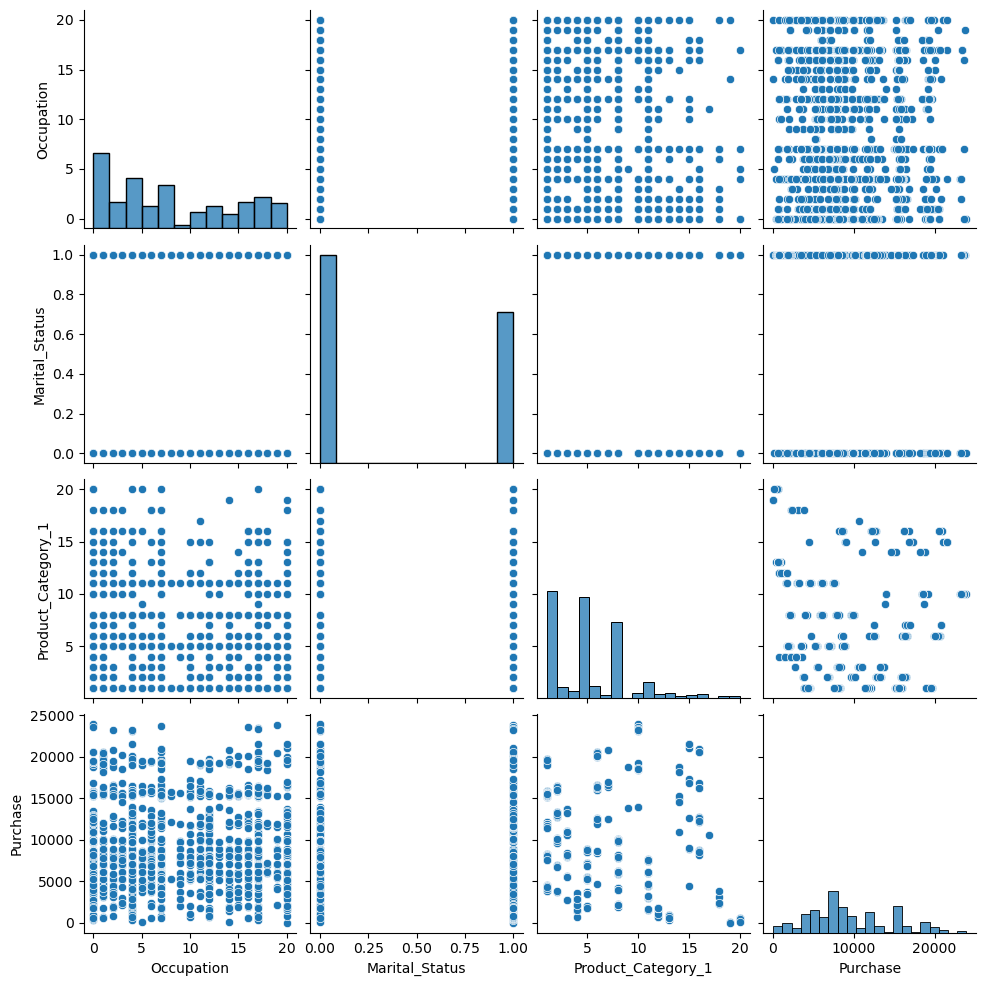

In [38]:
cols = ['Occupation',
        'Marital_Status',
        'Product_Category_1',
        'Purchase']

sns.pairplot(df[cols].sample(2000, random_state=42))
plt.show()

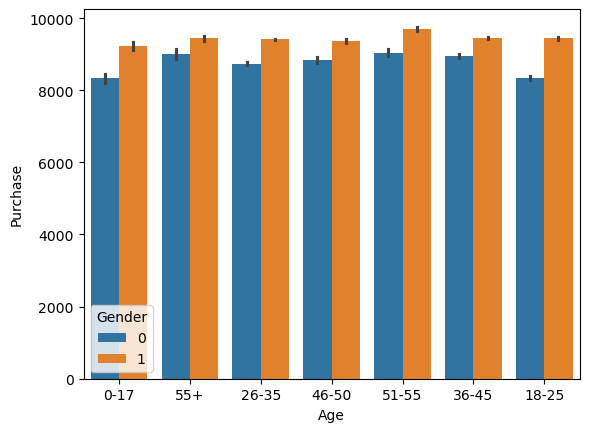

In [75]:
plot_df = df.dropna(subset=['Purchase'])
sns.barplot(data=plot_df,x='Age',y='Purchase',hue='Gender')
plt.show()

**Purchasing of men is high then women**

In [63]:
df = pd.concat([df_train, df_test], ignore_index=True)

In [64]:
df['Gender'].value_counts(dropna=False)

Gender
M    590031
F    193636
Name: count, dtype: int64

In [66]:
df_train = pd.read_csv('Downloads/train.csv')
df_test = pd.read_csv('Downloads/test.csv')

df = pd.concat([df_train, df_test], ignore_index=True)

In [72]:
df = pd.concat([df_train, df_test], ignore_index=True)

df['Gender'] = df['Gender'].map({'F':0,'M':1})

print(df['Gender'].value_counts(dropna=False))

Gender
1    590031
0    193636
Name: count, dtype: int64


<Axes: xlabel='Occupation', ylabel='Purchase'>

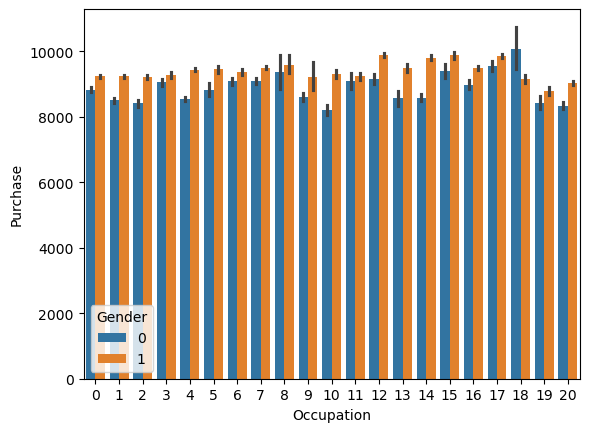

In [74]:
sns.barplot(data=df,x='Occupation',y='Purchase',hue='Gender')

<Axes: xlabel='Product_Category_1', ylabel='Purchase'>

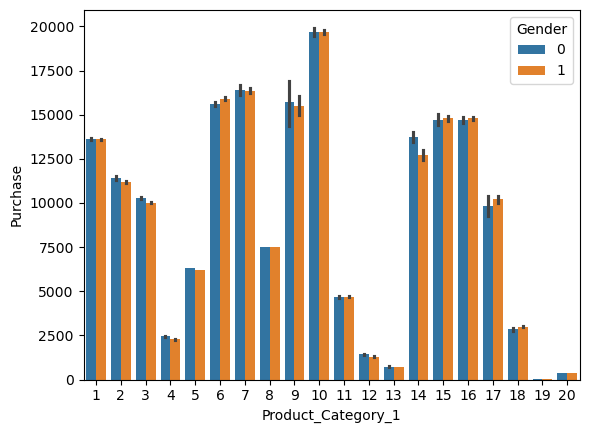

In [76]:
sns.barplot(data=df,x='Product_Category_1',y='Purchase',hue='Gender')

<Axes: xlabel='Product_Category_2', ylabel='Purchase'>

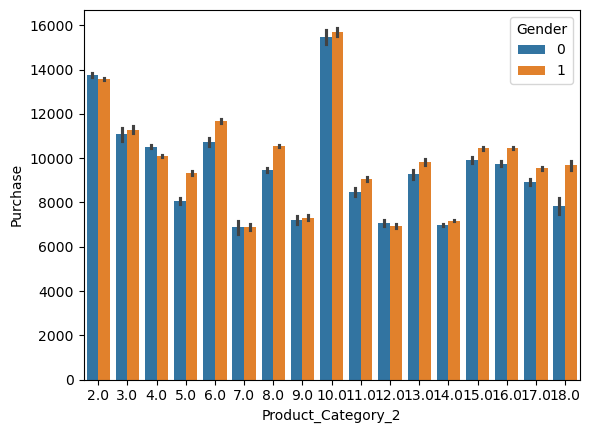

In [77]:
sns.barplot(data=df,x='Product_Category_2',y='Purchase',hue='Gender')

<Axes: xlabel='Product_Category_3', ylabel='Purchase'>

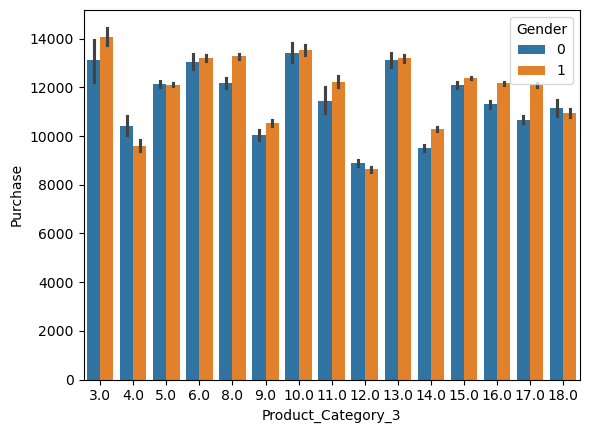

In [78]:
sns.barplot(data=df,x='Product_Category_3',y='Purchase',hue='Gender')

In [79]:
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,0,0-17,10,A,2,0,3,NaN,NaN,8370.0
1,1000001,P00248942,0,0-17,10,A,2,0,1,6.0,14.0,15200.0
2,1000001,P00087842,0,0-17,10,A,2,0,12,NaN,NaN,1422.0
3,1000001,P00085442,0,0-17,10,A,2,0,12,14.0,NaN,1057.0
4,1000002,P00285442,1,55+,16,C,4+,0,8,NaN,NaN,7969.0


In [80]:
#Feature scaling
df_test=df[df['Purchase'].isnull()]

In [84]:
df_train=df[~df['Purchase'].isnull()]

In [99]:
X=df_train.drop('Purchase',axis=1)

In [100]:
X.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000001,P00069042,0,0-17,10,A,2,0,3,NaN,NaN
1,1000001,P00248942,0,0-17,10,A,2,0,1,6.0,14.0
2,1000001,P00087842,0,0-17,10,A,2,0,12,NaN,NaN
3,1000001,P00085442,0,0-17,10,A,2,0,12,14.0,NaN
4,1000002,P00285442,1,55+,16,C,4+,0,8,NaN,NaN


In [101]:
y=df_train['Purchase']

In [102]:
y

0          8370.0
1         15200.0
2          1422.0
3          1057.0
4          7969.0
           ...   
550063      368.0
550064      371.0
550065      137.0
550066      365.0
550067      490.0
Name: Purchase, Length: 550068, dtype: float64

In [103]:
X.shape

(550068, 11)

In [104]:
y.shape

(550068,)

In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [106]:
X_train.drop('Product_ID',axis=1,inplace=True)
X_test.drop('Product_ID',axis=1,inplace=True)

In [108]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X_train.columns:
    if X_train[col].dtype == 'object':
        X_train[col] = le.fit_transform(X_train[col])
        X_test[col] = le.transform(X_test[col])

In [110]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [112]:
X_train.dtype

dtype('float64')

In [113]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

**Train Your Model**